# Regional Flux Inversion with FIPS

## Bayesian Inversion for Regional CH₄ Emissions

This notebook demonstrates solving a regional atmospheric inverse problem using Bayesian estimation.

### Problem Setup

**State (x):** Regional CH₄ flux anomalies on a spatial grid [µmol/m²/s]  
**Observations (z):** CH₄ concentration enhancements at observation sites [ppm]  
**Forward model:** z = H @ x (atmospheric transport from fluxes to concentrations)

### Approach

- **Synthetic Jacobian:** Distance-based Gaussian sensitivity (flux → concentration)
- **Synthetic Truth:** Gaussian emission hotspots within domain
- **Synthetic Observations:** Concentrations from truth + noise
- **Bayesian Estimation:** Recover fluxes from noisy concentration measurements

## 1. Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from fips.problems.flux import FluxInversion

# Configure plotting
plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

## 2. Configuration

In [2]:
# ==============================================================================
# RANDOM SEED
# ==============================================================================

RANDOM_SEED = 424

# ==============================================================================
# DOMAIN CONFIGURATION
# ==============================================================================

# Spatial domain (lat/lon bounds)
XMIN, XMAX = -112.0, -111.5  # longitude [deg]
YMIN, YMAX = 40.5, 41.0  # latitude [deg]
DX, DY = 0.05, 0.05  # grid spacing [deg]

# Time domain
T_START = pd.Timestamp("2024-01-01")
T_STOP = pd.Timestamp("2025-01-01")
STATE_FREQ = "MS"  # state frequency
OBS_FREQ = "D"  # observation frequency

# ==============================================================================
# OBSERVATION SITES
# ==============================================================================

N_SITES = 3  # number of observation locations

# ==============================================================================
# EMISSION HOTSPOTS (Truth field)
# ==============================================================================

N_HOTSPOTS = 2  # number of Gaussian emission centers
HOTSPOT_AMPLITUDE = 1.0  # peak flux [µmol/m²/s]
HOTSPOT_WIDTH = 0.1  # Gaussian width [deg] (std dev)

# ==============================================================================
# PRIOR CONFIGURATION
# ==============================================================================

PRIOR_MEAN = 0.05  # prior flux mean [µmol/m²/s]
PRIOR_STD_FRACTION = 0.5  # prior uncertainty as fraction of prior mean

# ==============================================================================
# JACOBIAN (SENSITIVITY)
# ==============================================================================

INFLUENCE_RADIUS = 0.3  # Gaussian influence radius [deg]

# ==============================================================================
# OBSERVATION ERROR
# ==============================================================================

OBS_NOISE_STD = 0.001  # observation noise [ppm]

print("Configuration:")
print(f"  Domain: [{XMIN}, {XMAX}] × [{YMIN}, {YMAX}] (spacing {DX}°)")
print(f"  Time: {T_START} to {T_STOP}")
print(f"  Observation sites: {N_SITES}")
print(f"  Hotspots: {N_HOTSPOTS} @ {HOTSPOT_AMPLITUDE} µmol/m²/s")
print(f"  Prior: {PRIOR_MEAN} ± {PRIOR_MEAN * PRIOR_STD_FRACTION} µmol/m²/s")

Configuration:
  Domain: [-112.0, -111.5] × [40.5, 41.0] (spacing 0.05°)
  Time: 2024-01-01 00:00:00 to 2025-01-01 00:00:00
  Observation sites: 3
  Hotspots: 2 @ 1.0 µmol/m²/s
  Prior: 0.05 ± 0.025 µmol/m²/s


## 3. Helper Functions

In [3]:
def build_grid(xmin, xmax, ymin, ymax, dx, dy):
    """
    Build spatial grid.

    Returns
    -------
    lons : array
        Longitude cell centers
    lats : array
        Latitude cell centers
    """
    lons = np.arange(xmin + dx / 2, xmax, dx)
    lats = np.arange(ymin + dy / 2, ymax, dy)
    return lons, lats


def build_obs_sites(n_sites, xmin, xmax, ymin, ymax, seed=42):
    """
    Generate random observation site locations within domain.

    Returns
    -------
    obs_lons : array
        Observation longitude coordinates
    obs_lats : array
        Observation latitude coordinates
    """
    np.random.seed(seed)
    obs_lons = np.random.uniform(xmin, xmax, n_sites)
    obs_lats = np.random.uniform(ymin, ymax, n_sites)
    return obs_lons, obs_lats


def gaussian_2d(x, y, x0, y0, sigma):
    """
    Evaluate 2D Gaussian.

    Parameters
    ----------
    x, y : array
        Coordinates (can be meshgrid)
    x0, y0 : float
        Gaussian center
    sigma : float
        Gaussian width

    Returns
    -------
    z : array
        Gaussian values
    """
    return np.exp(-0.5 * ((x - x0) ** 2 + (y - y0) ** 2) / sigma**2)


def build_truth_field(lons, lats, hotspots, amplitude, width):
    """
    Build synthetic truth field from Gaussian hotspots.

    Parameters
    ----------
    lons, lats : array
        Grid coordinates
    hotspots : list of (lon, lat)
        Hotspot center locations
    amplitude : float
        Peak flux amplitude
    width : float
        Gaussian width

    Returns
    -------
    flux : 2D array
        Flux field [n_lon × n_lat]
    """
    X, Y = np.meshgrid(lons, lats, indexing="ij")
    flux = np.zeros_like(X)

    for lon0, lat0 in hotspots:
        flux += amplitude * gaussian_2d(X, Y, lon0, lat0, width)

    return flux


def build_jacobian(obs_lons, obs_lats, state_lons, state_lats, influence_radius):
    """
    Build synthetic Jacobian using distance-based Gaussian sensitivity.

    H[i,j] = sensitivity of observation i to flux j
           = exp(-0.5 * (distance_ij / influence_radius)^2)

    Parameters
    ----------
    obs_lons, obs_lats : array
        Observation site coordinates
    state_lons, state_lats : array
        State grid coordinates
    influence_radius : float
        Gaussian influence radius

    Returns
    -------
    H : 2D array
        Jacobian [n_obs × n_state]
    """
    n_obs = len(obs_lons)
    n_lon = len(state_lons)
    n_lat = len(state_lats)
    n_state = n_lon * n_lat

    H = np.zeros((n_obs, n_state))

    idx = 0
    for i_lon in range(n_lon):
        for i_lat in range(n_lat):
            state_lon = state_lons[i_lon]
            state_lat = state_lats[i_lat]

            for i_obs in range(n_obs):
                # Great-circle distance (simplified for small distances)
                dlon = obs_lons[i_obs] - state_lon
                dlat = obs_lats[i_obs] - state_lat
                distance = np.sqrt(dlon**2 + dlat**2)

                # Gaussian sensitivity
                H[i_obs, idx] = np.exp(-0.5 * (distance / influence_radius) ** 2)

            idx += 1

    return H


def flatten_spatial_field(field_2d, time_index):
    """
    Flatten 2D spatial field into 1D state vector with time dimension.

    Parameters
    ----------
    field_2d : 2D array [n_lon × n_lat]
        Spatial field
    time_index : pd.DatetimeIndex or pd.IntervalIndex
        Time dimension

    Returns
    -------
    data : 1D array
        Flattened field repeated for each time step
    index : pd.MultiIndex
        (lon, lat, time) index
    """
    n_lon, n_lat = field_2d.shape
    n_time = len(time_index)

    data = np.tile(field_2d.ravel(), n_time)

    lon_idx = np.tile(np.repeat(range(n_lon), n_lat), n_time)
    lat_idx = np.tile(np.tile(range(n_lat), n_lon), n_time)
    time_idx = np.repeat(range(n_time), n_lon * n_lat)

    index = pd.MultiIndex.from_arrays(
        [lon_idx, lat_idx, time_idx], names=["lon_idx", "lat_idx", "time"]
    )

    return data, index


print("Helper functions loaded.")

Helper functions loaded.


## 4. Build Domain and Observation Network

In [4]:
# Build grid
lons, lats = build_grid(XMIN, XMAX, YMIN, YMAX, DX, DY)
X_grid, Y_grid = np.meshgrid(lons, lats, indexing="ij")

n_lon = len(lons)
n_lat = len(lats)
n_state_spatial = n_lon * n_lat

print(f"Spatial grid: {n_lon} × {n_lat} = {n_state_spatial} cells")

# Generate observation sites
obs_lons, obs_lats = build_obs_sites(N_SITES, XMIN, XMAX, YMIN, YMAX, seed=RANDOM_SEED)
location_mapper = {}
print(f"Observation sites: {N_SITES}")
for i, (lon, lat) in enumerate(zip(obs_lons, obs_lats, strict=False)):
    print(f"  Site {i}: ({lon:.3f}, {lat:.3f})")
    location_mapper[i] = (lat, lon)

# Generate hotspot locations
np.random.seed(RANDOM_SEED + 1)
hotspot_lons = np.random.uniform(XMIN, XMAX, N_HOTSPOTS)
hotspot_lats = np.random.uniform(YMIN, YMAX, N_HOTSPOTS)
hotspots = list(zip(hotspot_lons, hotspot_lats, strict=False))

print(f"Hotspots: {N_HOTSPOTS}")
for i, (lon, lat) in enumerate(hotspots):
    print(f"  Hotspot {i}: ({lon:.3f}, {lat:.3f})")

Spatial grid: 10 × 10 = 100 cells
Observation sites: 3
  Site 0: (-111.592, 40.759)
  Site 1: (-111.767, 40.871)
  Site 2: (-111.871, 40.712)
Hotspots: 2
  Hotspot 0: (-111.621, 40.909)
  Hotspot 1: (-111.865, 40.689)


## 5. Build Time Grids

In [5]:
# State time bins (fluxes)
state_times = pd.date_range(
    start=T_START, end=T_STOP, freq=STATE_FREQ, inclusive="left"
)
n_time_state = len(state_times)

# Observation time bins
obs_times = pd.date_range(start=T_START, end=T_STOP, freq=OBS_FREQ, inclusive="left")
n_time_obs = len(obs_times)

print(f"State time bins: {n_time_state}")
for t in state_times:
    print(f"  {t}")

print(f"\nObservation times: {n_time_obs}")
print(f"  {obs_times[0]} to {obs_times[-1]}")

State time bins: 12
  2024-01-01 00:00:00
  2024-02-01 00:00:00
  2024-03-01 00:00:00
  2024-04-01 00:00:00
  2024-05-01 00:00:00
  2024-06-01 00:00:00
  2024-07-01 00:00:00
  2024-08-01 00:00:00
  2024-09-01 00:00:00
  2024-10-01 00:00:00
  2024-11-01 00:00:00
  2024-12-01 00:00:00

Observation times: 366
  2024-01-01 00:00:00 to 2024-12-31 00:00:00


## 6. Build Jacobian

In [6]:
print("Building Jacobian...")
H = build_jacobian(obs_lons, obs_lats, lons, lats, INFLUENCE_RADIUS)

print(f"Jacobian shape: {H.shape}")
print(f"  Range: [{H.min():.4f}, {H.max():.4f}]")
print(f"  Mean sensitivity: {H.mean():.4f}")

Building Jacobian...
Jacobian shape: (3, 100)
  Range: [0.3265, 0.9996]
  Mean sensitivity: 0.7401


## 7. Generate Synthetic Truth and Observations

In [7]:
# Build truth field with seasonal cycle
print("Building truth field with seasonal cycle...")
truth_2d = build_truth_field(lons, lats, hotspots, HOTSPOT_AMPLITUDE, HOTSPOT_WIDTH)

# Create time-varying truth with seasonal cycle
# Amplitude varies from 0.5x to 1.5x the base, peaking in summer (day ~180)
truth_3d = np.zeros((n_lon, n_lat, n_time_state))

for t_idx, t in enumerate(state_times):
    # Seasonal cycle: sinusoid with peak in summer
    # day_of_year: 0-365, peak amplitude at day ~180 (June-July)
    day_of_year = t.dayofyear
    seasonal_factor = 1.0 + 0.5 * np.sin(2 * np.pi * (day_of_year - 152) / 365.25)
    truth_3d[:, :, t_idx] = seasonal_factor * truth_2d

# Reshape to flat vector in the correct order: iterate over lon, lat, then time
truth_data = truth_3d.reshape(-1)

# Create state index to match this ordering
state_index = pd.MultiIndex.from_product(
    [lons, lats, state_times], names=["lon", "lat", "time"]
)

truth_series = pd.Series(truth_data, index=state_index, name="truth")

print(f"Truth field: mean={truth_series.mean():.4f}, max={truth_series.max():.4f}")
print(f"  Seasonal range: {truth_series.min():.4f} to {truth_series.max():.4f}")

# Prior (uniform, independent of season)
prior_series = pd.Series(PRIOR_MEAN, index=state_index, name="prior")
print(f"Prior field: {prior_series.mean():.4f} ± {PRIOR_MEAN * PRIOR_STD_FRACTION:.4f}")

Building truth field with seasonal cycle...
Truth field: mean=0.4056, max=1.4847
  Seasonal range: 0.0006 to 1.4847
Prior field: 0.0500 ± 0.0250


## 8. Generate Synthetic Observations

In [8]:
print("Generating synthetic observations...")

# For each observation time, compute concentrations from time-varying fluxes
syn_obs_data = []
syn_obs_index = []

for t_obs in obs_times:
    # Find nearest state time
    idx = np.searchsorted(state_times, t_obs, side="left")
    if idx >= n_time_state:
        idx = n_time_state - 1

    # Extract truth for this time step from the 3D array
    state_flat = truth_3d[:, :, idx].ravel()

    # Compute concentrations
    conc = H @ state_flat

    # Add noise
    noise = np.random.normal(0, OBS_NOISE_STD, N_SITES)
    conc_noisy = conc + noise

    syn_obs_data.extend(conc_noisy)
    for i_site in range(N_SITES):
        syn_obs_index.append((i_site, t_obs))

obs_index = pd.MultiIndex.from_tuples(syn_obs_index, names=["site_idx", "time"])
syn_obs = pd.Series(syn_obs_data, index=obs_index, name="obs")

print(f"Observations: {len(syn_obs)}")
print(f"  Range: [{syn_obs.min():.6f}, {syn_obs.max():.6f}]")
print(f"  Mean: {syn_obs.mean():.6f}")

Generating synthetic observations...
Observations: 1098
  Range: [14.986829, 48.995507]
  Mean: 32.072807


## 9. Setup Inverse Problem

In [9]:
print("Setting up flux inversion problem...")

# Prior covariance (diagonal)
prior_std = PRIOR_MEAN * PRIOR_STD_FRACTION
S_x = pd.DataFrame(
    np.diag((prior_std**2) * np.ones(len(prior_series))),
    index=state_index,
    columns=state_index,
)

# Observation covariance (diagonal)
S_z = pd.DataFrame(
    np.diag((OBS_NOISE_STD**2) * np.ones(len(syn_obs))),
    index=obs_index,
    columns=obs_index,
)

# Forward operator: map state (lon, lat, time_state) to obs (site, time_obs)
# The state_index is organized as: (lon[0], lat[0], t[0]), (lon[0], lat[0], t[1]), ...,
#                                   (lon[0], lat[1], t[0]), (lon[0], lat[1], t[1]), ...
# So for each observation at time t_obs, we need to find all spatial cells at the corresponding state time
H_full = np.zeros((len(syn_obs), len(prior_series)))

obs_row = 0
for t_obs_idx, t_obs in enumerate(obs_times):
    # Find corresponding state time index
    state_time_idx = np.searchsorted(state_times, t_obs, side="left")
    if state_time_idx >= n_time_state:
        state_time_idx = n_time_state - 1

    # For each observation site at this time
    for site_idx in range(N_SITES):
        # Fill in Jacobian row for all spatial locations
        for lon_idx in range(n_lon):
            for lat_idx in range(n_lat):
                spatial_idx = lon_idx * n_lat + lat_idx
                col_pos = spatial_idx * n_time_state + state_time_idx
                H_full[obs_row, col_pos] = H[site_idx, spatial_idx]
        obs_row += 1

H_mat = pd.DataFrame(H_full, index=obs_index, columns=state_index)

# Create flux inversion problem
# The prepare functions will handle conversion of pandas objects to Vector/Matrix types
problem = FluxInversion(
    inventory=prior_series,
    concentrations=syn_obs,
    forward_operator=H_mat,
    prior_error=S_x,
    modeldata_mismatch=S_z,
)

print("Flux inversion problem configured.")
print(f"  State dimension: {len(prior_series)}")
print(f"  Observation dimension: {len(syn_obs)}")
print(f"  Jacobian shape: {H_full.shape}")

Setting up flux inversion problem...
Flux inversion problem configured.
  State dimension: 1200
  Observation dimension: 1098
  Jacobian shape: (1098, 1200)


## 10. Solve

In [10]:
print("Solving...")
problem.solve(estimator="bayesian")
print("✓ Solution complete")

Solving...
Solving using BayesianSolver...
Calculating Posterior Mean Model Estimate...
Calculating Kalman Gain Matrix...


Performing residual calculation...
Performing forward calculation...
Calculating Posterior Error Covariance Matrix...
Calculating Posterior Mean Observation Estimate...
Performing forward calculation...
✓ Solution complete


## 11. Diagnostics

In [11]:
# Extract results
x_post = problem.posterior.data.values
z_obs_vals = problem.obs.data.values
z_post = problem.posterior_obs.data.values
z_prior = problem.prior_obs.data.values

# Posterior state diagnostics
print("POSTERIOR STATE (FLUX)")
print(f"  Mean: {x_post.mean():.4f} µmol/m²/s")
print(f"  Std:  {x_post.std():.4f} µmol/m²/s")
print(f"  Range: [{x_post.min():.4f}, {x_post.max():.4f}]")

# Observation fit
print("\nOBSERVATION FIT")
print(f"  RMSE: {problem.estimator.RMSE:.6e} ppm")
print(f"  R²: {problem.estimator.R2:.4f}")
residuals = z_obs_vals - z_post
print(f"  Max residual: {np.abs(residuals).max():.6e} ppm")

# Uncertainty reduction
prior_std_full = np.sqrt(np.diag(problem.prior_error.values))
post_std_full = np.sqrt(np.diag(problem.posterior_error.values))
reduction = (1 - post_std_full / prior_std_full) * 100

print("\nUNCERTAINTY REDUCTION")
print(f"  Mean: {reduction.mean():.1f}%")
print(f"  Range: [{reduction.min():.1f}%, {reduction.max():.1f}%]")

# Information content
print("\nINFORMATION CONTENT")
print(f"  DOFS: {problem.estimator.DOFS:.1f}")
print(f"  Reduced χ²: {problem.estimator.reduced_chi2:.3f}")

Calculating Prior Mean Data Estimate...
Performing forward calculation...
POSTERIOR STATE (FLUX)
  Mean: 0.4156 µmol/m²/s
  Std:  0.1715 µmol/m²/s
  Range: [0.1128, 0.8114]

OBSERVATION FIT
Calculating Root Mean Square Error (RMSE)...
Performing residual calculation...
Performing forward calculation...
  RMSE: 9.948177e-04 ppm
Calculating Coefficient of determination (R-squared)...
  R²: 1.0000
  Max residual: 3.165918e-03 ppm

UNCERTAINTY REDUCTION
  Mean: 1.5%
  Range: [0.8%, 2.1%]

INFORMATION CONTENT
Calculating Averaging Kernel Matrix...
  DOFS: 36.0
Calculating Reduced Chi-squared statistic...
Performing residual calculation...
Performing forward calculation...
  Reduced χ²: 286.136


## 12. Visualization

(<Figure size 640x480 with 6 Axes>,
 array([<Axes: title={'center': 'Truth'}>,
        <Axes: title={'center': 'Prior'}>,
        <Axes: title={'center': 'Posterior'}>,
        <Axes: title={'center': 'Residual'}>], dtype=object))

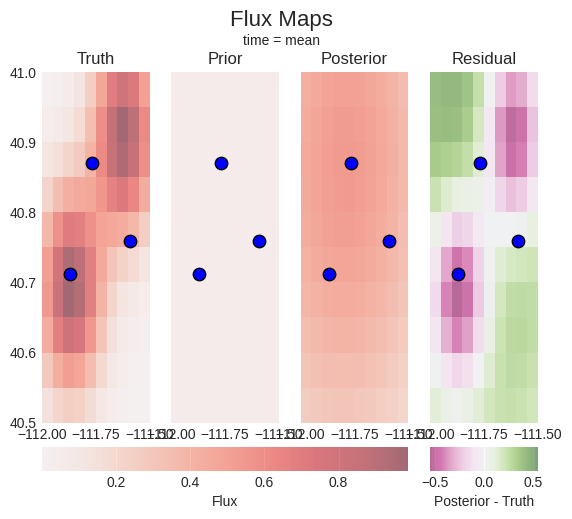

In [15]:
problem.plot.fluxes(truth=truth_series, sites=location_mapper)

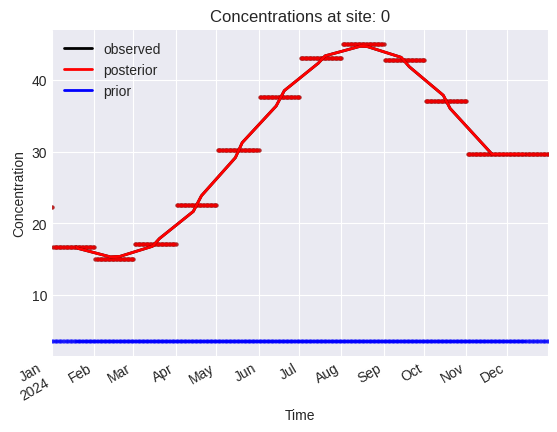

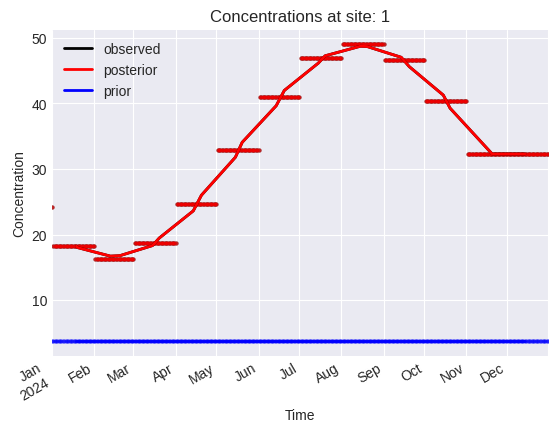

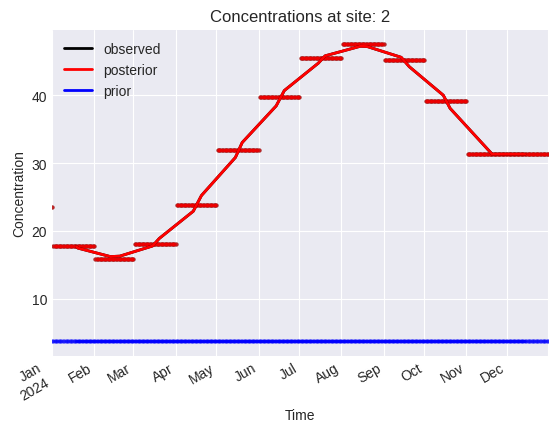

array([<Axes: title={'center': 'Concentrations at site: 0'}, xlabel='Time', ylabel='Concentration'>,
       <Axes: title={'center': 'Concentrations at site: 1'}, xlabel='Time', ylabel='Concentration'>,
       <Axes: title={'center': 'Concentrations at site: 2'}, xlabel='Time', ylabel='Concentration'>],
      dtype=object)

In [13]:
problem.plot.concentrations(location_dim="site_idx")

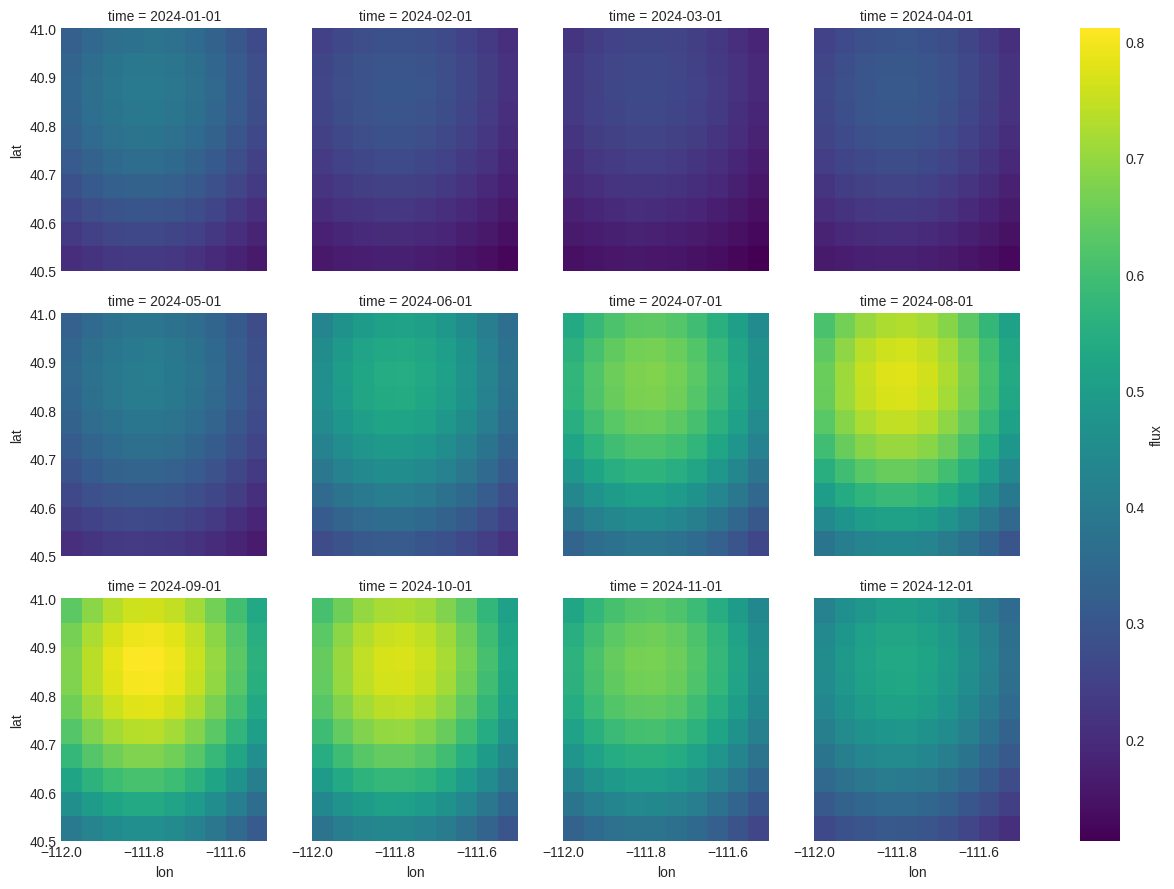

In [14]:
problem.xr.posterior["flux"].plot(x="lon", y="lat", col="time", col_wrap=4)